# Production Economy: Eggertsson & Mehrotra (2014) + Lu (2015)

This notebook replicates the New Keynesian production economy results from:

- **Eggertsson & Mehrotra (2014)** "A Model of Secular Stagnation", sections 4–6  
- **Lu (2015)** "Bubbles in a Secular Stagnation Economy", section 3

The steady state is characterised by aggregate supply (AS) and aggregate demand (AD)
curves in $(Y, \Pi)$ space, each with two regimes.

Sections:
1. [Setup](#1-Setup)
2. [Sanity Checks](#2-Sanity-Checks)
3. [AS/AD — Normal Equilibrium (EM Figure 2)](#3-AS/AD-Normal-Equilibrium)
4. [AS/AD — Secular Stagnation (EM Figure 3)](#4-AS/AD-Secular-Stagnation)
5. [Bubble Effect on AS/AD (Lu 2015 Figure 3)](#5-Bubble-Effect-on-AS/AD)

---
## 1  Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import src.calibration as cal

from src.production_model import (
    potential_output,
    aggregate_supply,
    aggregate_demand,
    pi_kink,
    find_equilibrium,
    natural_rate_production,
)
from src.endowment_model import bubble_upper_bound, fundamental_rate

FIG_DIR = os.path.join(os.path.dirname(os.getcwd()), 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

# Convenience aliases
BETA    = cal.BETA
D_H     = cal.D
D_L     = cal.D_L
G       = cal.G
ALPHA   = cal.ALPHA
L_BAR   = cal.L_BAR
GAMMA   = cal.GAMMA
PHI_PI  = cal.PHI_PI
PI_STAR = cal.PI_STAR
I_STAR  = cal.I_STAR

# Derived constants used across sections
Y_F    = potential_output(L_BAR, ALPHA)
PI_K   = pi_kink(I_STAR, PHI_PI, PI_STAR)
A_MAX  = bubble_upper_bound(Y_F, D_L, BETA)  # max bubble at D_L

# Pi grid for plotting: covers both ZLB and normal regimes
PI_GRID = np.linspace(0.80, 1.25, 600)

print(f'Y_f = {Y_F:.4f},  Pi_kink = {PI_K:.4f},  A_max (D_L) = {A_MAX:.4f}')

Y_f = 1.0000,  Pi_kink = 1.0100,  A_max (D_L) = 0.0634


---
## 2  Sanity Checks

In [2]:
print('='*60)
for D, label in [(D_H, 'D_H (pre-shock)'), (D_L, 'D_L (post-deleveraging)')]:
    eq = find_equilibrium(D, G, BETA, PHI_PI, PI_STAR, I_STAR,
                          GAMMA, ALPHA, L_BAR)
    Rn = natural_rate_production(D, G, Y_F, BETA)
    print(f'\n{label}')
    print(f'  Potential output Y_f : {Y_F:.4f}')
    print(f'  Pi_kink              : {PI_K:.4f}')
    print(f'  Natural rate R^n     : {Rn:.4f}  (r^n = {Rn-1:.4f})')
    print(f'  Equilibrium Y        : {eq["Y"]:.4f}')
    print(f'  Equilibrium Pi       : {eq["Pi"]:.4f}')
    print(f'  Regime               : {eq["regime"]}')
    print(f'  i_nominal            : {eq["i_nominal"]:.4f}')
print('='*60)

eq_H = find_equilibrium(D_H, G, BETA, PHI_PI, PI_STAR, I_STAR, GAMMA, ALPHA, L_BAR)
eq_L = find_equilibrium(D_L, G, BETA, PHI_PI, PI_STAR, I_STAR, GAMMA, ALPHA, L_BAR)
assert eq_H['regime'] == 'normal', 'D_H should give normal regime'
assert eq_L['regime'] == 'zlb',    'D_L should give ZLB regime'
print('\nRegime assertions passed.')

# --- D_H cross-check at Pi = Pi_star = 1.01 --------------------------------
print('\n' + '-'*60)
print(f'D = D_H: curve values at Pi = Pi_star = {PI_STAR}')
AS_at_pistar = float(aggregate_supply(PI_STAR, Y_F, GAMMA, ALPHA))
AD_at_pistar = float(aggregate_demand(PI_STAR, D_H, G, BETA, PHI_PI, PI_STAR, I_STAR))
print(f'  AS(Pi_star) = {AS_at_pistar:.4f}  (= Y_f = {Y_F:.4f} since Pi_star >= 1)')
print(f'  AD(Pi_star) = {AD_at_pistar:.4f}')
print(f'  AD - AS     = {AD_at_pistar - AS_at_pistar:+.4f}')
print(f'  (positive => AD > AS at target, so equilibrium Pi > Pi_star, as in EM Fig 2)')
print('-'*60)


D_H (pre-shock)
  Potential output Y_f : 1.0000
  Pi_kink              : 1.0100
  Natural rate R^n     : 1.0727  (r^n = 0.0727)
  Equilibrium Y        : 1.0000
  Equilibrium Pi       : 1.0943
  Regime               : normal
  i_nominal            : 0.1739

D_L (post-deleveraging)
  Potential output Y_f : 1.0000
  Pi_kink              : 1.0100
  Natural rate R^n     : 0.9642  (r^n = -0.0358)
  Equilibrium Y        : 0.9182
  Equilibrium Pi       : 0.9227
  Regime               : zlb
  i_nominal            : 0.0000

Regime assertions passed.

------------------------------------------------------------
D = D_H: curve values at Pi = Pi_star = 1.01
  AS(Pi_star) = 1.0000  (= Y_f = 1.0000 since Pi_star >= 1)
  AD(Pi_star) = 1.0601
  AD - AS     = +0.0601
  (positive => AD > AS at target, so equilibrium Pi > Pi_star, as in EM Fig 2)
------------------------------------------------------------


---
## 3  AS/AD — Normal Equilibrium

Replicates **EM (2014) Figure 2**.  
Pre-shock economy with $D = D_H$.  The Taylor rule is active and the
equilibrium is at full employment (point A).

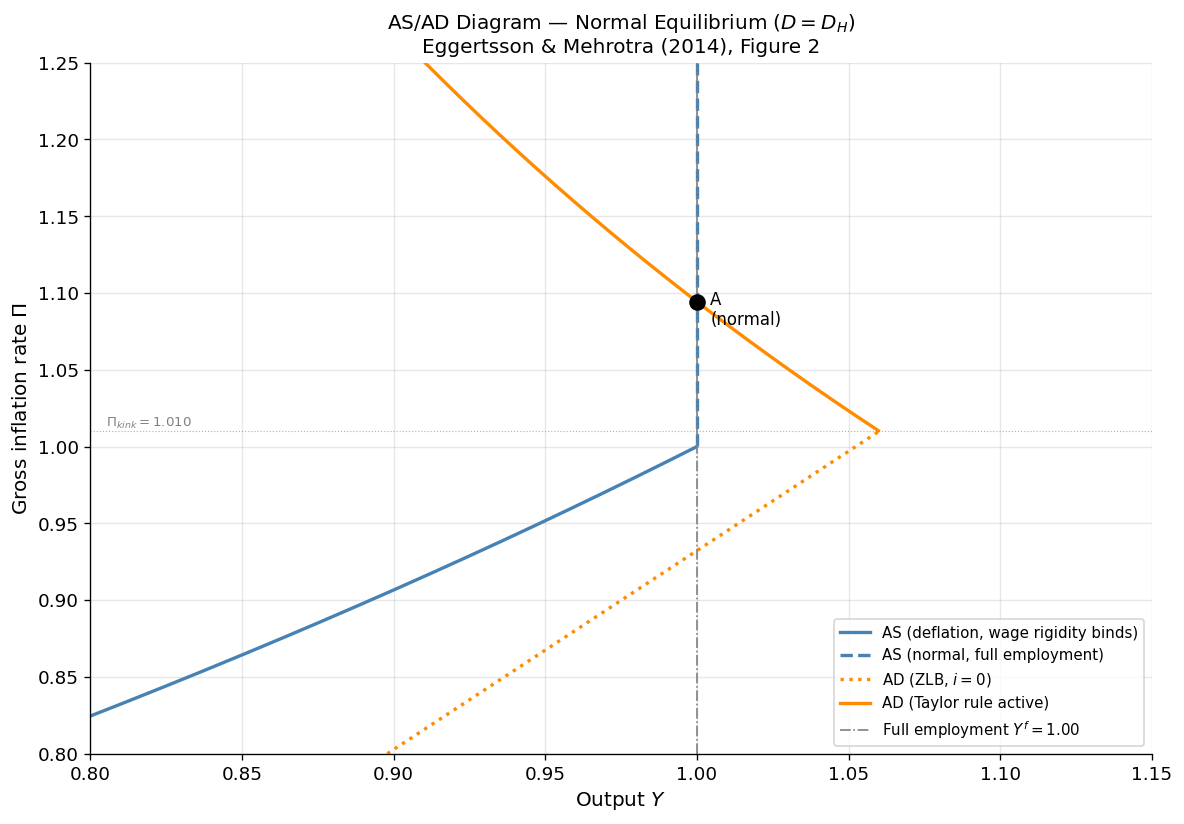

Saved: figures/fig3_asad_normal.{pdf,png}


In [3]:
# Curves — Y on x-axis, Pi on y-axis
AS_vals  = aggregate_supply(PI_GRID, Y_F, GAMMA, ALPHA)
AD_H_vals = aggregate_demand(PI_GRID, D_H, G, BETA, PHI_PI, PI_STAR, I_STAR)

# Equilibrium point A
Y_A, Pi_A = eq_H['Y'], eq_H['Pi']

fig, ax = plt.subplots(figsize=(10, 7))

# AS: two segments — deflation (Pi<1) and normal (Pi>=1)
mask_as_def  = PI_GRID < 1.0
mask_as_norm = PI_GRID >= 1.0
ax.plot(AS_vals[mask_as_def],  PI_GRID[mask_as_def],
        color='steelblue', lw=2, label='AS (deflation, wage rigidity binds)')
ax.plot(AS_vals[mask_as_norm], PI_GRID[mask_as_norm],
        color='steelblue', lw=2, ls='--', label='AS (normal, full employment)')

# AD: two segments — ZLB (Pi < Pi_kink) and Taylor rule (Pi >= Pi_kink)
mask_ad_zlb  = PI_GRID < PI_K
mask_ad_norm = PI_GRID >= PI_K
ax.plot(AD_H_vals[mask_ad_zlb],  PI_GRID[mask_ad_zlb],
        color='darkorange', lw=2, ls=':', label='AD (ZLB, $i=0$)')
ax.plot(AD_H_vals[mask_ad_norm], PI_GRID[mask_ad_norm],
        color='darkorange', lw=2, label='AD (Taylor rule active)')

# Full employment vertical line
ax.axvline(Y_F, color='grey', lw=1.0, ls='-.', label=f'Full employment $Y^f={Y_F:.2f}$')

# ZLB kink horizontal marker
ax.axhline(PI_K, color='grey', lw=0.7, ls=':', alpha=0.6)
ax.text(0.805, PI_K + 0.003, f'$\\Pi_{{kink}}={PI_K:.3f}$', fontsize=8, color='grey')

# Equilibrium point A
ax.scatter([Y_A], [Pi_A], color='black', zorder=6, s=80)
ax.annotate('A\n(normal)', (Y_A, Pi_A),
            textcoords='offset points', xytext=(8, -14),
            fontsize=10, color='black')

ax.set_xlim(0.80, 1.15)
ax.set_ylim(0.80, 1.25)
ax.set_xlabel('Output $Y$', fontsize=12)
ax.set_ylabel('Gross inflation rate $\\Pi$', fontsize=12)
ax.set_title('AS/AD Diagram — Normal Equilibrium ($D = D_H$)\n'
             'Eggertsson & Mehrotra (2014), Figure 2', fontsize=12)
ax.legend(fontsize=9, loc='lower right')

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig3_asad_normal.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'fig3_asad_normal.png'), bbox_inches='tight')
plt.show()
print('Saved: figures/fig3_asad_normal.{pdf,png}')

---
## 4  AS/AD — Secular Stagnation

Replicates **EM (2014) Figure 3**.  
The deleveraging shock tightens the collateral constraint from $D_H$ to $D_L$,
shifting AD inward.  The new equilibrium (B) is in the ZLB regime with
output below potential — secular stagnation.

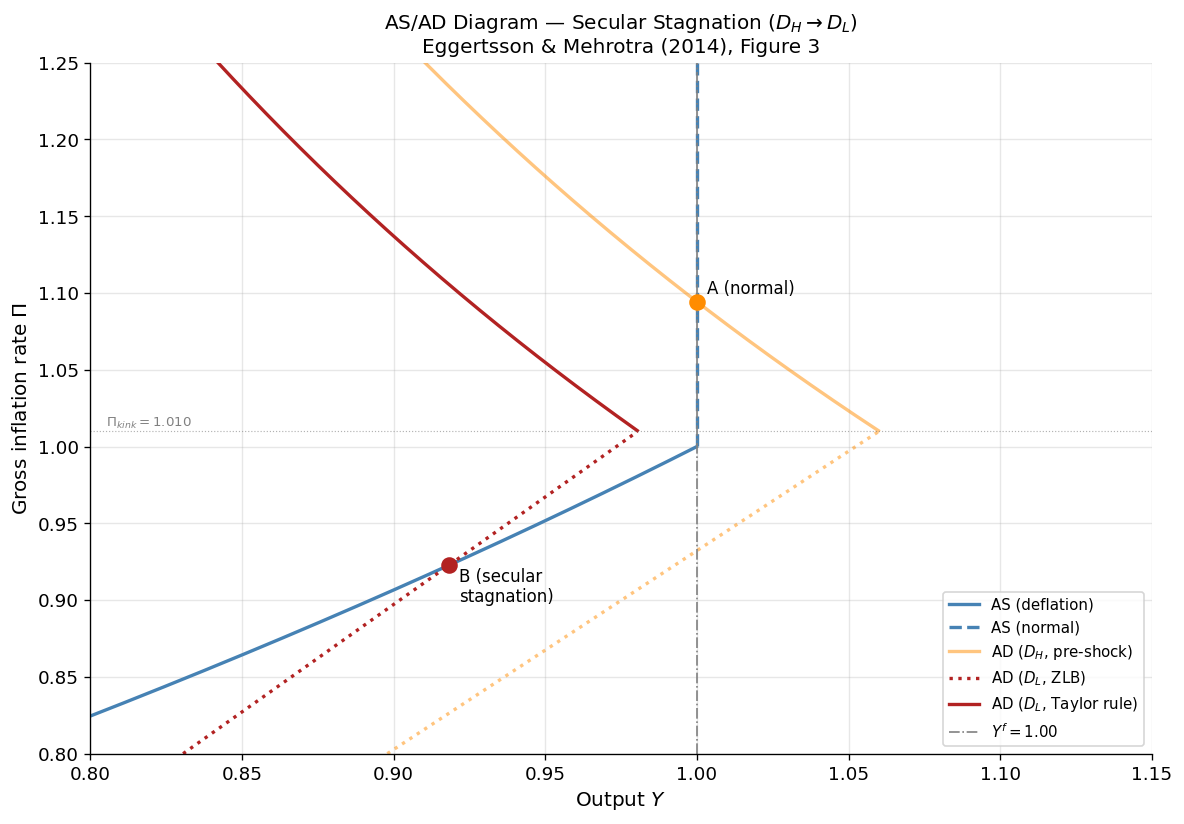

Saved: figures/fig4_asad_stagnation.{pdf,png}


In [4]:
AD_L_vals = aggregate_demand(PI_GRID, D_L, G, BETA, PHI_PI, PI_STAR, I_STAR)

# Equilibrium points
Y_A, Pi_A = eq_H['Y'], eq_H['Pi']
Y_B, Pi_B = eq_L['Y'], eq_L['Pi']

fig, ax = plt.subplots(figsize=(10, 7))

# AS (same in both regimes)
ax.plot(AS_vals[mask_as_def],  PI_GRID[mask_as_def],
        color='steelblue', lw=2, label='AS (deflation)')
ax.plot(AS_vals[mask_as_norm], PI_GRID[mask_as_norm],
        color='steelblue', lw=2, ls='--', label='AS (normal)')

# AD — D_H (pre-shock)
ax.plot(AD_H_vals[mask_ad_zlb],  PI_GRID[mask_ad_zlb],
        color='darkorange', lw=2, ls=':', alpha=0.5)
ax.plot(AD_H_vals[mask_ad_norm], PI_GRID[mask_ad_norm],
        color='darkorange', lw=2, alpha=0.5, label='AD ($D_H$, pre-shock)')

# AD — D_L (post-shock)
ax.plot(AD_L_vals[mask_ad_zlb],  PI_GRID[mask_ad_zlb],
        color='firebrick', lw=2, ls=':', label='AD ($D_L$, ZLB)')
ax.plot(AD_L_vals[mask_ad_norm], PI_GRID[mask_ad_norm],
        color='firebrick', lw=2, label='AD ($D_L$, Taylor rule)')

# Full employment line
ax.axvline(Y_F, color='grey', lw=1.0, ls='-.', label=f'$Y^f = {Y_F:.2f}$')

# ZLB kink
ax.axhline(PI_K, color='grey', lw=0.7, ls=':', alpha=0.6)
ax.text(0.805, PI_K + 0.003, f'$\\Pi_{{kink}}={PI_K:.3f}$', fontsize=8, color='grey')

# Equilibrium dots
ax.scatter([Y_A], [Pi_A], color='darkorange', zorder=6, s=80)
ax.annotate('A (normal)', (Y_A, Pi_A),
            textcoords='offset points', xytext=(6, 5), fontsize=10)

ax.scatter([Y_B], [Pi_B], color='firebrick', zorder=6, s=80)
ax.annotate('B (secular\nstagnation)', (Y_B, Pi_B),
            textcoords='offset points', xytext=(6, -22), fontsize=10)

ax.set_xlim(0.80, 1.15)
ax.set_ylim(0.80, 1.25)
ax.set_xlabel('Output $Y$', fontsize=12)
ax.set_ylabel('Gross inflation rate $\\Pi$', fontsize=12)
ax.set_title('AS/AD Diagram — Secular Stagnation ($D_H \\to D_L$)\n'
             'Eggertsson & Mehrotra (2014), Figure 3', fontsize=12)
ax.legend(fontsize=9, loc='lower right')

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig4_asad_stagnation.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'fig4_asad_stagnation.png'), bbox_inches='tight')
plt.show()
print('Saved: figures/fig4_asad_stagnation.{pdf,png}')

---
## 5  Bubble Effect on AS/AD

Replicates **Lu (2015) Figure 3**.  
$D = D_L$ is held fixed.  A rational bubble of size $A$ enters
households' portfolios, shifting AD **rightward** by raising aggregate
demand at every inflation rate.  Even a bubble of $A = A_{\max}/2$
suffices to restore full employment.

A_max (at D_L = 0.259) = 0.0634


<>:68: SyntaxWarning: invalid escape sequence '\P'
<>:73: SyntaxWarning: invalid escape sequence '\P'
<>:68: SyntaxWarning: invalid escape sequence '\P'
<>:73: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_142213/1884274954.py:68: SyntaxWarning: invalid escape sequence '\P'
  ax.text(0.805, PI_K + 0.004, f'$\Pi_{{kink}}={PI_K:.3f}$', fontsize=8, color='grey')
/tmp/ipykernel_142213/1884274954.py:73: SyntaxWarning: invalid escape sequence '\P'
  ax.set_ylabel('Gross inflation rate $\Pi$', fontsize=12)


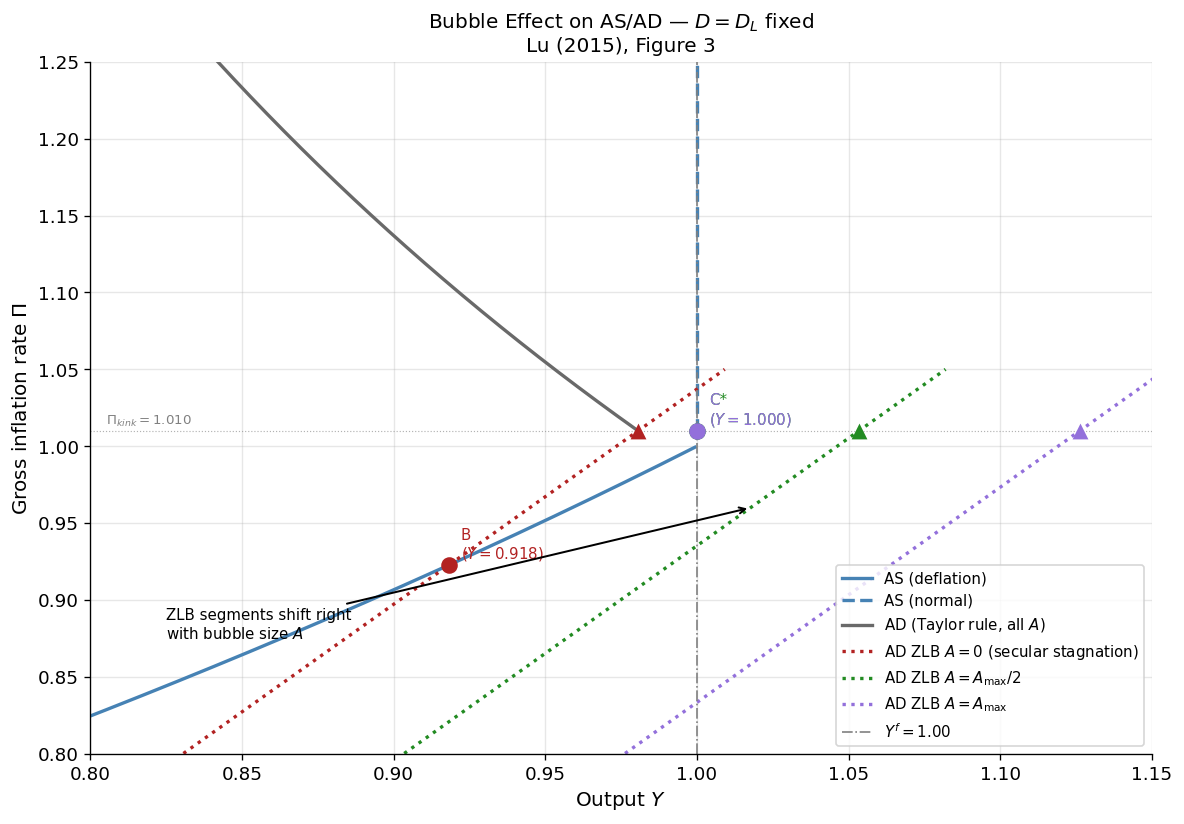

Saved: figures/fig5_asad_bubble.{pdf,png}


In [5]:
print(f'A_max (at D_L = {D_L}) = {A_MAX:.4f}')

bubble_cases = [
    (0.0,          'firebrick',    'B',  '$A = 0$ (secular stagnation)'),
    (A_MAX * 0.5,  'forestgreen',  'C*', r'$A = A_{\max}/2$'),
    (A_MAX,        'mediumpurple', 'C',  r'$A = A_{\max}$'),
]

# Pi grids
PI_ZLB_EXT = np.linspace(GAMMA + 0.001, 1.05, 400)  # ZLB branch, extended past Pi_kink
PI_TAYLOR  = np.linspace(PI_K,          1.25, 300)   # Taylor rule segment

fig, ax = plt.subplots(figsize=(10, 7))

# --- AS ---
AS_def    = aggregate_supply(PI_ZLB_EXT[PI_ZLB_EXT < 1.0],
                             Y_F, GAMMA, ALPHA)
PI_def    = PI_ZLB_EXT[PI_ZLB_EXT < 1.0]
AS_taylor = aggregate_supply(PI_TAYLOR, Y_F, GAMMA, ALPHA)
ax.plot(AS_def,    PI_def,    color='steelblue', lw=2,      label='AS (deflation)')
ax.plot(AS_taylor, PI_TAYLOR, color='steelblue', lw=2, ls='--', label='AS (normal)')

# --- Taylor rule segment — plotted once in dark grey ---
AD_taylor_shared = aggregate_demand(PI_TAYLOR, D_L, G, BETA, PHI_PI, PI_STAR,
                                    I_STAR, A_bubble=0.0)  # same for all A
ax.plot(AD_taylor_shared, PI_TAYLOR,
        color='dimgrey', lw=2, label='AD (Taylor rule, all $A$)')

# --- Three ZLB segments (extended past Pi_kink) ---
# Compute ZLB branch directly so it extends beyond Pi_kink without switching regime
coeff_zlb = (1 + BETA) / BETA
for A, color, point_label, legend_label in bubble_cases:
    AD_zlb = D_L + coeff_zlb * (1 + G) * D_L * PI_ZLB_EXT + coeff_zlb * A

    ax.plot(AD_zlb, PI_ZLB_EXT,
            color=color, lw=2, ls=':', label=f'AD ZLB {legend_label}')

    # Triangle marker at Pi_kink showing where each curve transitions
    Y_kink = D_L + coeff_zlb * (1 + G) * D_L * PI_K + coeff_zlb * A
    ax.scatter([Y_kink], [PI_K], color=color, marker='^',
               zorder=7, s=90, linewidths=0)

    # Equilibrium dot
    eq_b = find_equilibrium(D_L, G, BETA, PHI_PI, PI_STAR, I_STAR,
                            GAMMA, ALPHA, L_BAR, A_bubble=A)
    Y_eq, Pi_eq = eq_b['Y'], eq_b['Pi']
    ax.scatter([Y_eq], [Pi_eq], color=color, zorder=6, s=80)
    ax.annotate(f'{point_label}\n($Y={Y_eq:.3f}$)', (Y_eq, Pi_eq),
                textcoords='offset points', xytext=(7, 4),
                fontsize=9, color=color)

# --- Annotation with arrow pointing at the ZLB bundle ---
# Arrow tip lands on the middle ZLB curve (A=A_max/2) at Pi ~ 0.96
A_mid   = A_MAX * 0.5
Y_arrow = D_L + coeff_zlb * (1 + G) * D_L * 0.96 + coeff_zlb * A_mid
ax.annotate('ZLB segments shift right\nwith bubble size $A$',
            xy=(Y_arrow, 0.96),
            xytext=(0.825, 0.875),
            fontsize=9, color='black',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
            ha='left')

# Full employment line
ax.axvline(Y_F, color='grey', lw=1.0, ls='-.', label=f'$Y^f = {Y_F:.2f}$')

# ZLB kink reference line
ax.axhline(PI_K, color='grey', lw=0.7, ls=':', alpha=0.6)
ax.text(0.805, PI_K + 0.004, f'$\Pi_{{kink}}={PI_K:.3f}$', fontsize=8, color='grey')

ax.set_xlim(0.80, 1.15)
ax.set_ylim(0.80, 1.25)
ax.set_xlabel('Output $Y$', fontsize=12)
ax.set_ylabel('Gross inflation rate $\Pi$', fontsize=12)
ax.set_title('Bubble Effect on AS/AD — $D = D_L$ fixed\n'
             'Lu (2015), Figure 3', fontsize=12)
ax.legend(fontsize=9, loc='lower right')

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig5_asad_bubble.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'fig5_asad_bubble.png'), bbox_inches='tight')
plt.show()
print('Saved: figures/fig5_asad_bubble.{pdf,png}')